# Modeling – SelectKBest + KNN – John Bouckaert & Hugo Fiévet

## Introduction

Dans ce notebook, nous appliquons le modèle KNN au jeu de données issu de la sélection de variables réalisée avec la méthode `SelectKBest`.

L’objectif est d’évaluer les performances de cette combinaison en suivant une démarche complète : choix d’un indicateur pertinent, entraînement du modèle, optimisation des hyperparamètres, validation croisée, analyse du surapprentissage éventuel et interprétation des résultats.

Cette combinaison permettra notamment de comparer l’effet d’une sélection automatique fondée sur le lien statistique avec la variable cible par rapport à la sélection personnelle utilisée dans le notebook précédent.

## Table of contents

1. [Loading the selected datasets](#1-loading-the-selected-datasets)  
2. [Choice of the performance metric](#2-choice-of-the-performance-metric)  
3. [Baseline KNN model](#3-baseline-knn-model)  
4. [Hyperparameter tuning with GridSearchCV](#4-hyperparameter-tuning-with-gridsearchcv)  
5. [Cross-validation and performance evaluation](#5-cross-validation-and-performance-evaluation)  
6. [Overfitting and underfitting analysis](#6-overfitting-and-underfitting-analysis)  
7. [Conclusion](#conclusion)

## 1. Loading the selected datasets

Dans cette première étape, nous chargeons les jeux de données correspondant à la sélection de variables obtenue avec `SelectKBest`.

L’objectif est de vérifier que les dimensions des jeux d’entraînement et de test sont cohérentes avant de commencer la modélisation avec le modèle KNN.

In [1]:
import pandas as pd

# Chargement des jeux de données sélectionnés
X_train = pd.read_csv("xtrain_KB.csv")
X_test = pd.read_csv("xtest_KB.csv")
y_train = pd.read_csv("ytrain.csv")
y_test = pd.read_csv("ytest.csv")

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)

print("\nColonnes de X_train :")
print(X_train.columns.tolist())

print("\nAperçu de X_train :")
print(X_train.head())

Dimensions de X_train : (1047, 15)
Dimensions de X_test : (262, 15)
Dimensions de y_train : (1047, 1)
Dimensions de y_test : (262, 1)

Colonnes de X_train :
['parch', 'fare', 'has_cabin', 'pclass_1', 'pclass_3', 'sex_female', 'sex_male', 'embarked_C', 'embarked_S', 'title_grouped_Miss', 'title_grouped_Mr', 'title_grouped_Mrs', 'family_group_alone', 'family_group_large_family', 'family_group_small_family']

Aperçu de X_train :
      parch      fare  has_cabin  pclass_1  pclass_3  sex_female  sex_male  \
0 -0.447597 -0.499246          0         0         1           1         0   
1 -0.447597 -0.090614          0         0         0           1         0   
2  1.872374 -0.017890          0         0         1           1         0   
3 -0.447597 -0.509988          0         0         1           0         1   
4 -0.447597 -0.501292          0         0         1           1         0   

   embarked_C  embarked_S  title_grouped_Miss  title_grouped_Mr  \
0           0           0         

Les fichiers correspondant à la sélection obtenue par `SelectKBest` ont bien été chargés et leurs dimensions sont cohérentes. Le jeu d’entraînement contient **1047 observations** et **15 variables**, tandis que le jeu de test contient **262 observations** et les mêmes **15 variables**. Les variables cibles `y_train` et `y_test` ont également été récupérées correctement.

La liste des colonnes confirme que cette combinaison repose sur les variables les mieux classées par le test ANOVA dans le notebook précédent. On y retrouve des variables liées au tarif, à la cabine, à la classe, au sexe, au port d’embarquement, au titre et à la structure familiale regroupée. Toutes les variables explicatives sont numériques, ce qui rend le jeu de données directement exploitable pour un modèle KNN.

L’aperçu de `X_train` montre que le jeu de données utilisé pour cette modélisation est propre, homogène et prêt à être soumis au modèle. La prochaine étape consiste à rappeler l’indicateur de performance principal retenu pour évaluer et optimiser cette combinaison.

## 2. Choice of the performance metric

**Dans ce notebook, nous choisissons le F1-score comme indicateur principal de performance.**

Ce choix s’explique par le fait que la variable cible n’est pas parfaitement équilibrée : la proportion de passagers non survivants est plus élevée que celle des survivants. Dans ce contexte, l’accuracy seule pourrait donner une vision trop simplifiée des performances du modèle.

Le F1-score constitue un compromis entre la précision et le rappel. Il permet donc de mieux évaluer la capacité du modèle à identifier correctement les survivants tout en limitant les erreurs de classification. Cet indicateur est particulièrement pertinent lorsque l’on souhaite tenir compte à la fois des faux positifs et des faux négatifs.

## 3. Baseline KNN model

Dans cette étape, nous entraînons un premier modèle KNN avec des paramètres simples afin d’obtenir une référence de départ.

L’objectif est d’évaluer les performances initiales du modèle avant toute optimisation des hyperparamètres. Cette première évaluation servira de point de comparaison pour la suite du notebook.

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# y sous forme de vecteur
y_train_series = y_train.iloc[:, 0]
y_test_series = y_test.iloc[:, 0]

# Modèle KNN de base
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train, y_train_series)

# Prédictions
y_pred_baseline = knn_baseline.predict(X_test)

# Évaluation
accuracy_baseline = accuracy_score(y_test_series, y_pred_baseline)
f1_baseline = f1_score(y_test_series, y_pred_baseline)

print("Accuracy du modèle KNN de base :", round(accuracy_baseline, 4))
print("F1-score du modèle KNN de base :", round(f1_baseline, 4))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test_series, y_pred_baseline))

print("\nClassification report :")
print(classification_report(y_test_series, y_pred_baseline))

Accuracy du modèle KNN de base : 0.8053
F1-score du modèle KNN de base : 0.7488

Matrice de confusion :
[[135  27]
 [ 24  76]]

Classification report :
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       162
           1       0.74      0.76      0.75       100

    accuracy                           0.81       262
   macro avg       0.79      0.80      0.79       262
weighted avg       0.81      0.81      0.81       262



Le modèle KNN de base obtient une **accuracy de 0.8053** et un **F1-score de 0.7488** sur le jeu de test. Ces résultats montrent que, même sans optimisation particulière, la combinaison entre la sélection `SelectKBest` et le modèle KNN fournit déjà des performances correctes.

La matrice de confusion indique que le modèle classe correctement **135 non-survivants** et **76 survivants**. En revanche, il se trompe sur **27 passagers** prédits survivants alors qu’ils ne le sont pas, et sur **24 survivants** prédits à tort comme non-survivants. Le modèle semble ici un peu plus équilibré entre les deux classes que dans le notebook précédent, même si les erreurs restent encore non négligeables.

Le rapport de classification confirme cette impression. Pour la classe `0`, le rappel est de **0.83**, tandis que pour la classe `1`, il atteint **0.76**. Le **F1-score de la classe des survivants** est de **0.75**, ce qui montre que le modèle détecte mieux cette classe que le modèle de base obtenu avec la sélection personnelle.

Dans l’ensemble, ce premier modèle constitue une base de comparaison satisfaisante. Les performances sont déjà correctes, et la détection des survivants paraît légèrement mieux équilibrée. La prochaine étape consistera donc à optimiser les hyperparamètres du KNN afin d’évaluer si cette combinaison peut encore être améliorée.

## 4. Hyperparameter tuning with GridSearchCV

Dans cette étape, nous cherchons à améliorer les performances du modèle KNN en optimisant ses principaux hyperparamètres.

Nous utilisons `GridSearchCV` afin de tester automatiquement plusieurs combinaisons de paramètres et d’identifier celle qui maximise le **F1-score** en validation croisée. Cette démarche permet de choisir un modèle plus adapté que le modèle de base, tout en limitant le risque de choix arbitraire.

In [3]:
from sklearn.model_selection import GridSearchCV

# Grille d'hyperparamètres
param_grid = {
    "n_neighbors": list(range(1, 32, 2)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# GridSearchCV
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_knn.fit(X_train, y_train_series)

print("Meilleurs hyperparamètres :")
print(grid_knn.best_params_)

print("\nMeilleur F1-score moyen en validation croisée :")
print(round(grid_knn.best_score_, 4))

results_knn = pd.DataFrame(grid_knn.cv_results_)
results_knn = results_knn.sort_values(by="rank_test_score").reset_index(drop=True)

print("\nTop 10 des combinaisons testées :")
print(results_knn[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].head(10))

Meilleurs hyperparamètres :
{'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}

Meilleur F1-score moyen en validation croisée :
0.7155

Top 10 des combinaisons testées :
                                              params  mean_test_score  \
0  {'metric': 'manhattan', 'n_neighbors': 19, 'we...         0.715459   
1  {'metric': 'manhattan', 'n_neighbors': 25, 'we...         0.714747   
2  {'metric': 'manhattan', 'n_neighbors': 15, 'we...         0.713443   
3  {'metric': 'manhattan', 'n_neighbors': 23, 'we...         0.712747   
4  {'metric': 'manhattan', 'n_neighbors': 11, 'we...         0.711389   
5  {'metric': 'manhattan', 'n_neighbors': 21, 'we...         0.710972   
6  {'metric': 'manhattan', 'n_neighbors': 17, 'we...         0.708610   
7  {'metric': 'manhattan', 'n_neighbors': 13, 'we...         0.707333   
8  {'metric': 'euclidean', 'n_neighbors': 11, 'we...         0.707201   
9  {'metric': 'manhattan', 'n_neighbors': 27, 'we...         0.706733   

   std_test_

La recherche par grille montre que la meilleure combinaison d’hyperparamètres est obtenue avec une distance **Manhattan**, un nombre de voisins égal à **19** et une pondération **uniforme**. Ce résultat suggère qu’un modèle KNN relativement lissé, fondé sur un voisinage assez large, généralise mieux que les versions plus locales du modèle.

Le meilleur **F1-score moyen en validation croisée** est de **0.7155**. Ce score est légèrement supérieur à celui observé dans le notebook `P + KNN`, ce qui laisse penser que la sélection `SelectKBest` fournit ici un ensemble de variables légèrement plus favorable au modèle KNN.

On remarque également que plusieurs combinaisons proches, notamment avec une distance Manhattan et un nombre de voisins compris entre 15 et 25, donnent des résultats similaires. Cela montre que les performances du KNN restent relativement stables autour des meilleurs réglages, même si la distance Manhattan apparaît ici encore comme la plus adaptée.

## 5. Performance evaluation

Dans cette étape, nous évaluons sur le jeu de test le meilleur modèle KNN obtenu par optimisation.

L’objectif est de comparer ses performances à celles du modèle de base, en utilisant les mêmes indicateurs : accuracy, F1-score, matrice de confusion et rapport de classification.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Meilleur modèle trouvé par GridSearchCV
best_knn = grid_knn.best_estimator_

# Prédictions sur le jeu de test
y_pred_best = best_knn.predict(X_test)

# Scores
accuracy_best = accuracy_score(y_test_series, y_pred_best)
f1_best = f1_score(y_test_series, y_pred_best)

print("Accuracy du meilleur modèle KNN :", round(accuracy_best, 4))
print("F1-score du meilleur modèle KNN :", round(f1_best, 4))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test_series, y_pred_best))

print("\nClassification report :")
print(classification_report(y_test_series, y_pred_best))

print("\nRappel des performances du modèle de base :")
print("Accuracy baseline :", round(accuracy_baseline, 4))
print("F1-score baseline :", round(f1_baseline, 4))

Accuracy du meilleur modèle KNN : 0.8168
F1-score du meilleur modèle KNN : 0.7551

Matrice de confusion :
[[140  22]
 [ 26  74]]

Classification report :
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       162
           1       0.77      0.74      0.76       100

    accuracy                           0.82       262
   macro avg       0.81      0.80      0.80       262
weighted avg       0.82      0.82      0.82       262


Rappel des performances du modèle de base :
Accuracy baseline : 0.8053
F1-score baseline : 0.7488


Le meilleur modèle KNN obtenu par `GridSearchCV` améliore légèrement les performances du modèle de base. L’**accuracy** passe de **0.8053** à **0.8168**, tandis que le **F1-score** progresse de **0.7488** à **0.7551**. L’optimisation des hyperparamètres apporte donc un gain réel, mais plus modéré que dans le notebook `P + KNN`.

La matrice de confusion montre que le modèle classe correctement **140 non-survivants** et **74 survivants**. Par rapport au modèle de base, le nombre de faux positifs diminue de **27 à 22**, tandis que le nombre de faux négatifs augmente légèrement de **24 à 26**. Le modèle optimisé réduit donc certaines erreurs, mais l’amélioration globale reste relativement limitée.

Le rapport de classification confirme cette progression modérée. Pour la classe `1`, le **F1-score** passe de **0.75** à **0.76**, avec une précision de **0.77** et un rappel de **0.74**. Le modèle reste donc relativement équilibré entre les deux classes, mais sans gain spectaculaire après optimisation.

Dans l’ensemble, cette combinaison `KB + KNN` donne des résultats corrects et légèrement améliorés après optimisation. Elle semble toutefois moins performante que la combinaison `P + KNN`, qui atteignait un meilleur F1-score sur le jeu de test. Cela suggère que, dans ce cas précis, la sélection personnelle conserve peut-être des variables ou une structure plus favorable au modèle KNN que la sélection automatique par `SelectKBest`.

## 6. Overfitting and underfitting analysis

Dans cette étape, nous comparons les performances du meilleur modèle sur le jeu d’entraînement et sur le jeu de test afin d’évaluer la présence éventuelle de surapprentissage ou de sous-apprentissage.

L’objectif est de vérifier si le modèle généralise correctement, ou s’il obtient des performances trop élevées sur les données d’entraînement par rapport aux données de test.

In [5]:
# Prédictions sur le jeu d'entraînement
y_pred_train = best_knn.predict(X_train)

# Scores sur le train
accuracy_train = accuracy_score(y_train_series, y_pred_train)
f1_train = f1_score(y_train_series, y_pred_train)

print("Performance du meilleur modèle sur le jeu d'entraînement :")
print("Accuracy train :", round(accuracy_train, 4))
print("F1-score train :", round(f1_train, 4))

print("\nPerformance du meilleur modèle sur le jeu de test :")
print("Accuracy test  :", round(accuracy_best, 4))
print("F1-score test  :", round(f1_best, 4))

print("\nÉcart entre train et test :")
print("Écart accuracy :", round(accuracy_train - accuracy_best, 4))
print("Écart F1-score :", round(f1_train - f1_best, 4))

Performance du meilleur modèle sur le jeu d'entraînement :
Accuracy train : 0.8176
F1-score train : 0.7497

Performance du meilleur modèle sur le jeu de test :
Accuracy test  : 0.8168
F1-score test  : 0.7551

Écart entre train et test :
Écart accuracy : 0.0008
Écart F1-score : -0.0054


L’analyse des performances sur les jeux d’entraînement et de test ne met pas en évidence de surapprentissage. En effet, les résultats sont presque identiques sur les deux jeux : l’**accuracy** vaut **0.8176** sur le train contre **0.8168** sur le test, et le **F1-score** vaut **0.7497** sur le train contre **0.7551** sur le test.

Les écarts observés sont donc extrêmement faibles : **0.0008** pour l’accuracy et **-0.0054** pour le F1-score. Cela signifie que le modèle ne mémorise pas excessivement les données d’entraînement et qu’il généralise correctement sur des données non vues.

Le fait que le F1-score soit très légèrement meilleur sur le jeu de test que sur le jeu d’entraînement peut sembler surprenant, mais ce n’est pas anormal. Cela peut simplement indiquer que le jeu de test est ici un peu plus favorable au modèle que certaines partitions internes du jeu d’entraînement. Ce résultat ne traduit donc pas un problème méthodologique particulier.

Dans l’ensemble, cette combinaison `KB + KNN` semble produire un modèle stable, sans surapprentissage visible. Les performances restent correctes, mais l’amélioration apportée par l’optimisation reste modérée, et les résultats demeurent légèrement inférieurs à ceux obtenus avec la combinaison `P + KNN`.

### Learning curve

Afin de compléter l’analyse du surapprentissage et du sous-apprentissage, nous utilisons une courbe d’apprentissage.  
Cette représentation permet d’observer l’évolution des performances du modèle sur le jeu d’entraînement et en validation croisée en fonction de la quantité de données utilisées.

L’objectif est de vérifier si le modèle bénéficie encore d’un apport de données supplémentaires, et d’identifier plus finement un éventuel surapprentissage ou sous-apprentissage.

Résultats de la courbe d'apprentissage :
   train_size  f1_train_mean  f1_train_std  f1_validation_mean  \
0          83         0.6151        0.1771              0.5498   
1         167         0.7266        0.0418              0.6485   
2         251         0.7071        0.0176              0.6499   
3         334         0.7138        0.0186              0.6550   
4         418         0.7210        0.0146              0.6605   
5         502         0.7299        0.0117              0.6770   
6         585         0.7312        0.0195              0.6764   
7         669         0.7367        0.0141              0.7025   
8         753         0.7425        0.0144              0.7029   
9         837         0.7458        0.0120              0.7144   

   f1_validation_std  
0             0.1792  
1             0.0480  
2             0.0373  
3             0.0457  
4             0.0388  
5             0.0513  
6             0.0519  
7             0.0453  
8             0.0379  
9 

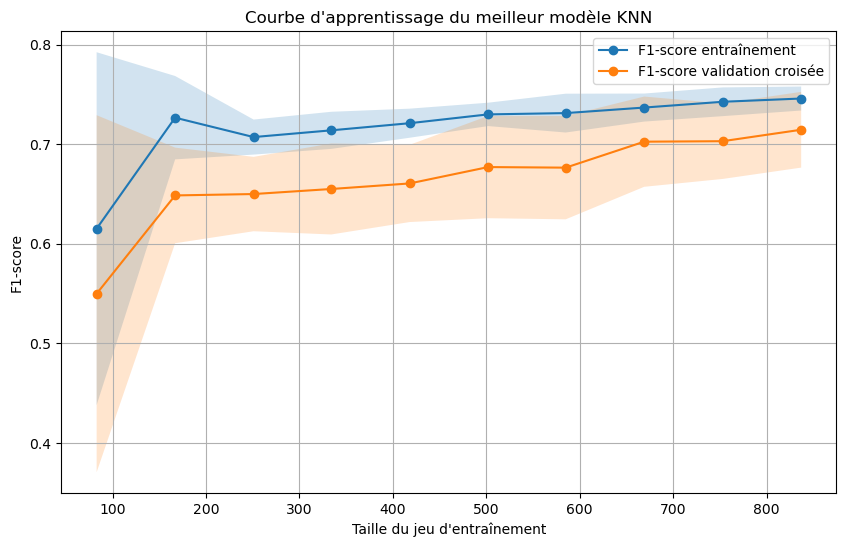

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Calcul de la courbe d'apprentissage
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_knn,
    X=X_train,
    y=y_train_series,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyennes et écarts-types
train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)

val_scores_mean = val_scores.mean(axis=1)
val_scores_std = val_scores.std(axis=1)

# Affichage des résultats numériques
learning_curve_df = pd.DataFrame({
    "train_size": train_sizes,
    "f1_train_mean": train_scores_mean,
    "f1_train_std": train_scores_std,
    "f1_validation_mean": val_scores_mean,
    "f1_validation_std": val_scores_std
})

print("Résultats de la courbe d'apprentissage :")
print(learning_curve_df.round(4))

# Graphique
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, marker="o", label="F1-score entraînement")
plt.plot(train_sizes, val_scores_mean, marker="o", label="F1-score validation croisée")

plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_scores_mean - val_scores_std,
    val_scores_mean + val_scores_std,
    alpha=0.2
)

plt.title("Courbe d'apprentissage du meilleur modèle KNN")
plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()

La courbe d’apprentissage montre que le modèle KNN progresse rapidement lorsque la taille du jeu d’entraînement augmente, puis tend à se stabiliser. Pour les plus petites tailles d’échantillon, les scores sont plus instables, comme le montrent les écarts-types élevés observés au début. Cela est particulièrement visible pour `train_size = 83`, où les performances varient fortement d’un pli de validation à l’autre.

Lorsque la taille du jeu d’entraînement augmente, le **F1-score sur l’entraînement** et le **F1-score en validation croisée** se rapprochent progressivement. À partir d’environ **650 à 850 observations**, les deux courbes deviennent relativement stables, avec un F1-score d’entraînement proche de **0.74 à 0.75** et un F1-score de validation croisée qui atteint environ **0.70 à 0.71**.

L’écart entre les deux courbes reste modéré sur la fin, ce qui ne suggère pas de surapprentissage important. Si le modèle surapprenait fortement, la courbe d’entraînement resterait nettement au-dessus de la courbe de validation. Ici, l’écart subsiste mais reste raisonnable, ce qui indique une capacité de généralisation satisfaisante.

On n’observe pas non plus de sous-apprentissage manifeste. Les scores finaux restent corrects et cohérents avec les résultats obtenus précédemment sur le jeu de test. Le modèle semble donc atteindre un compromis acceptable entre apprentissage et généralisation.

Enfin, la fin de la courbe laisse penser que l’ajout de nouvelles données pourrait encore apporter une légère amélioration, mais sans changement spectaculaire. Le modèle semble déjà proche de son niveau de performance stable pour cette combinaison de variables et d’hyperparamètres.

## Conclusion

Dans ce notebook, nous avons évalué la combinaison entre la sélection de variables obtenue par `SelectKBest` et le modèle KNN.

Le modèle de base a d’abord fourni des résultats corrects, puis l’optimisation des hyperparamètres par `GridSearchCV` a permis une légère amélioration des performances. Le meilleur modèle obtenu utilise une distance **Manhattan**, un nombre de voisins égal à **19** et une pondération **uniforme**. Sur le jeu de test, ce modèle atteint une **accuracy de 0.8168** et un **F1-score de 0.7551**.

L’analyse des performances sur les jeux d’entraînement et de test, ainsi que la courbe d’apprentissage, ne mettent pas en évidence de surapprentissage important. Le modèle semble relativement stable et généralise correctement.

Cette combinaison `KB + KNN` constitue donc une solution correcte pour la prédiction de la survie des passagers du Titanic. Elle reste toutefois légèrement moins performante que la combinaison `P + KNN`, qui obtenait un meilleur F1-score sur le jeu de test après optimisation.